## Memory Usage vs Cluster Size

Analyze memory consumption for each algorithm across different cluster sizes.

## All Timing Steps Comparison

Plot all timing metrics as line charts to see how each step scales with cluster size.

## Performance Summary

Summary statistics and key insights from the benchmark data.

In [265]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set style for better-looking plots with colorblind-friendly palette
sns.set_style("whitegrid")
sns.set_palette("colorblind")  # Colorblind-friendly palette
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

In [266]:
# Load benchmark results
results_file = Path("benchmark_results.json")

if not results_file.exists():
    print(f"Error: {results_file} not found. Please run benchmark.py first.")
    print("Usage: python3 benchmark.py")
else:
    with open(results_file, "r") as f:
        results = json.load(f)
    
    print(f"Loaded benchmark data from {results_file}")
    print(f"Timestamp: {results['metadata']['timestamp']}")
    print(f"Cluster sizes: {results['metadata']['cluster_sizes']}")
    print(f"Algorithms: {results['metadata']['algorithms']}")
    print(f"Runs per size: {results['metadata']['runs_per_size']}")
    print(f"Total data points: {len(results['data'])}")

Loaded benchmark data from benchmark_results.json
Timestamp: 2026-05-11T18:14:07.722652
Cluster sizes: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]
Algorithms: ['hpa']
Runs per size: 5
Total data points: 95


In [267]:
# Convert results to DataFrame
data_rows = []

for point in results['data']:
    row = {
        'cluster_size': point['cluster_size'],
        'algorithm': point['algorithm'],
        'run': point['run'],
    }
    # Add all timing metrics
    row.update(point['timings'])
    data_rows.append(row)

df = pd.DataFrame(data_rows)

# Rename columns for clarity
rename_mapping = {
    'preprocessed': 'intra cluster pathfinding',
    'inter_edges': 'found inter edges'
}
# Only rename columns that exist
rename_mapping = {old: new for old, new in rename_mapping.items() if old in df.columns}
df = df.rename(columns=rename_mapping)

# Calculate total time by summing all timing metrics
timing_cols = [col for col in df.columns if col not in ['cluster_size', 'algorithm', 'run'] 
               and 'memory' not in col.lower() and 'length' not in col.lower() and 'intra' not in col.lower() and 'inter' not in col.lower()]
df['pathfinding_time'] = df[timing_cols].sum(axis=1)

timing_cols = [col for col in df.columns if col not in ['cluster_size', 'algorithm', 'run'] 
               and 'memory' not in col.lower() and 'length' not in col.lower() and 'graph' not in col.lower() and 'overall' not in col.lower()]
df['preprocessing_time'] = df[timing_cols].sum(axis=1)

# Display basic info
print("DataFrame shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nAlgorithms:", df['algorithm'].unique())
print("Cluster sizes:", sorted(df['cluster_size'].unique()))

DataFrame shape: (95, 12)

Column names:
['cluster_size', 'algorithm', 'run', 'found inter edges', 'intra cluster pathfinding', 'finish_abstract_graph', 'found_graph_path', 'found_overall_path', 'max_memory', 'path_length', 'pathfinding_time', 'preprocessing_time']

First few rows:
   cluster_size algorithm  run  found inter edges  intra cluster pathfinding  \
0            20       hpa    1           1.204245                   6.008726   
1            20       hpa    2           1.205580                   6.046200   
2            20       hpa    3           1.211229                   6.084552   
3            20       hpa    4           1.203131                   6.018747   
4            20       hpa    5           1.204167                   5.973297   

   finish_abstract_graph  found_graph_path  found_overall_path  max_memory  \
0               0.000808          0.002487            0.001062        7.88   
1               0.000807          0.002461            0.001086        7.85   
2 

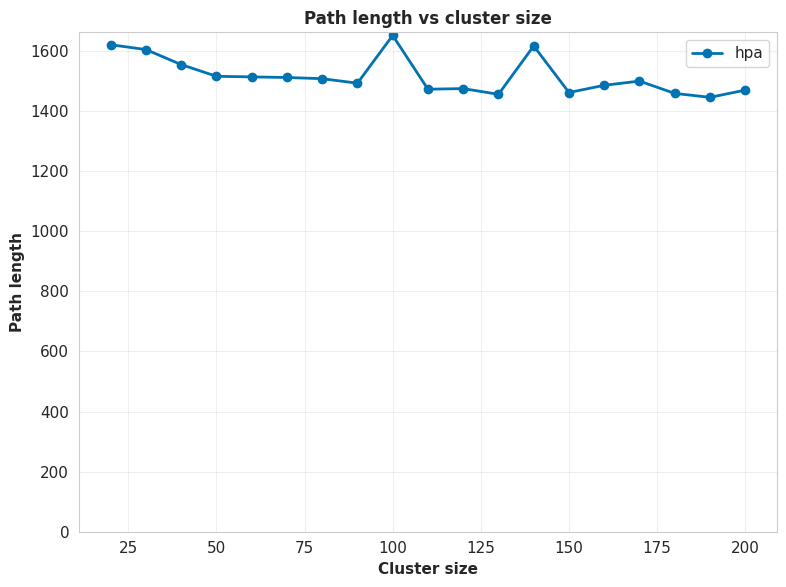

In [268]:
if 'path_length' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    for algo in sorted(df['algorithm'].unique()):
        algo_data = df[df['algorithm'] == algo]
        grouped = algo_data.groupby('cluster_size')['path_length'].agg(['mean'])
        
        ax.plot(grouped.index, grouped['mean'], 
                   marker='o', label=algo, linewidth=2, markersize=6)
    
    ax.set_xlabel('Cluster size', fontsize=11, fontweight='bold')
    ax.set_ylabel('Path length', fontsize=11, fontweight='bold')
    ax.set_title('Path length vs cluster size', fontsize=12, fontweight='bold')
    ax.set_ylim([0, None])
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


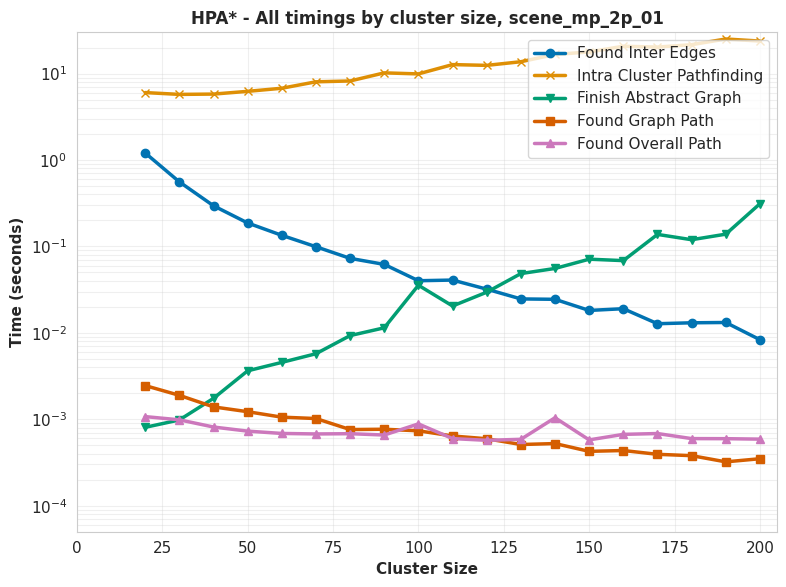

All timing steps plotted with logarithmic scale


In [269]:
# Plot all timing steps for each algorithm on same graph with different colors
timing_metrics = [col for col in df.columns if col not in ['cluster_size', 'algorithm', 'run'] 
                  and 'memory' not in col.lower() and 'length' not in col.lower() and 'time' not in col.lower()]

algorithms = sorted(df['algorithm'].unique())

# Use colorblind-friendly palette
colorblind_palette = sns.color_palette("colorblind", len(timing_metrics))
colors = colorblind_palette

fig, axes = plt.subplots(1, len(algorithms), figsize=(8, 6))

# Ensure axes is always iterable
if len(algorithms) == 1:
    axes = [axes]

markers = ['o', 'x', 'v', 's', '^', '*']

for algo_idx, algo in enumerate(algorithms):
    ax = axes[algo_idx]
    algo_data = df[df['algorithm'] == algo]
    
    for metric_idx, metric in enumerate(timing_metrics):
        # Skip if metric doesn't exist or all zeros
        if metric not in algo_data.columns:
            continue
        
        grouped = algo_data.groupby('cluster_size')[metric].agg(['mean'])
        
        # Skip if all values are zero
        if grouped['mean'].sum() == 0:
            continue
        
        ax.plot(grouped.index, grouped['mean'], marker=markers[metric_idx], linewidth=2.5, 
                markersize=6, color=colors[metric_idx], label=metric.replace('_', ' ').title())
    
    ax.set_xlabel('Cluster Size', fontsize=11, fontweight='bold')
    ax.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
    ax.set_title(f'{algo.upper()}* - All timings by cluster size, scene_mp_2p_01', fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.set_ylim([5e-5, 30])
    ax.set_xlim([0, 205])
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("All timing steps plotted with logarithmic scale")

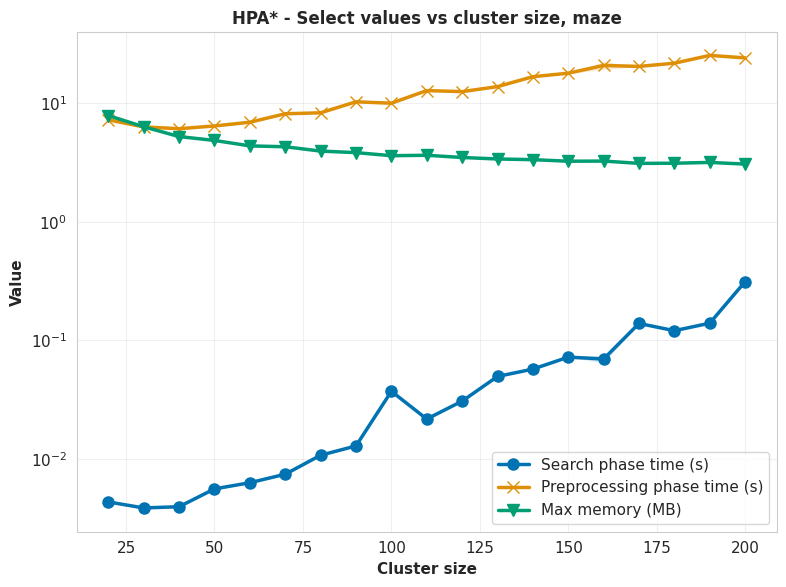

Plot: Total time vs cluster size


In [270]:
# Plot total time vs cluster size
if 'pathfinding_time' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    for algo in sorted(df['algorithm'].unique()):
        algo_data = df[df['algorithm'] == algo]
        grouped = algo_data.groupby('cluster_size')['pathfinding_time'].agg(['mean', 'std'])
        
        ax.plot(grouped.index, grouped['mean'], 
                marker='o', label="Search phase time (s)", linewidth=2.5, markersize=8)
        ax.fill_between(grouped.index, 
                        grouped['mean'] - grouped['std'],
                        grouped['mean'] + grouped['std'],
                        alpha=0.2)
        
        grouped = algo_data.groupby('cluster_size')['preprocessing_time'].agg(['mean', 'std'])
        
        ax.plot(grouped.index, grouped['mean'], 
                marker='x', label="Preprocessing phase time (s)", linewidth=2.5, markersize=8)
        ax.fill_between(grouped.index, 
                        grouped['mean'] - grouped['std'],
                        grouped['mean'] + grouped['std'],
                        alpha=0.2)
        
        grouped = algo_data.groupby('cluster_size')['max_memory'].agg(['mean', 'std'])
        
        ax.plot(grouped.index, grouped['mean'], 
                marker='v', label="Max memory (MB)", linewidth=2.5, markersize=8)
        ax.fill_between(grouped.index, 
                        grouped['mean'] - grouped['std'],
                        grouped['mean'] + grouped['std'],
                        alpha=0.2)
        
    ax.set_xlabel('Cluster size', fontsize=11, fontweight='bold')
    ax.set_ylabel('Value', fontsize=11, fontweight='bold')
    ax.set_title('HPA* - Select values vs cluster size, maze', fontsize=12, fontweight='bold')
    # ax.set_ylim([0, None])
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    plt.tight_layout()
    plt.show()
    
    print("Plot: Total time vs cluster size")